<a href="https://colab.research.google.com/github/oybekabdusattorov3337-wq/week8_lab/blob/main/Lab_SVM_NumPy_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

Imports loaded.


## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [2]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

X shape: (300, 2)
Class counts: [150 150]


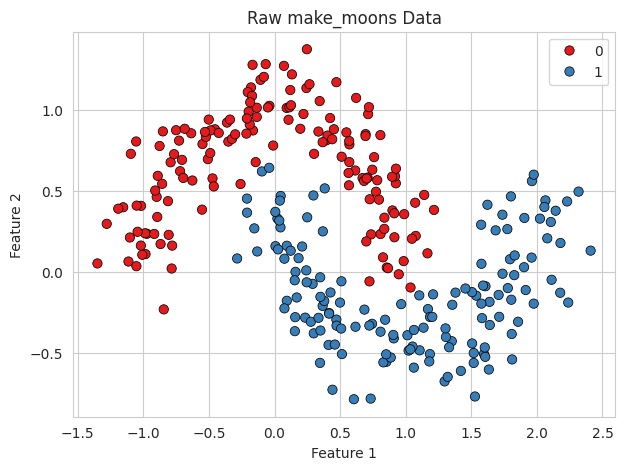

In [3]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Train shape: (225, 2) Test shape: (75, 2)


In [6]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [7]:
svm_np = LinearSVMFromScratch(C=0.5, learning_rate=0.001, n_iters=2500)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

NumPy Linear SVM accuracy: 0.8267
sklearn LinearSVC accuracy: 0.8533


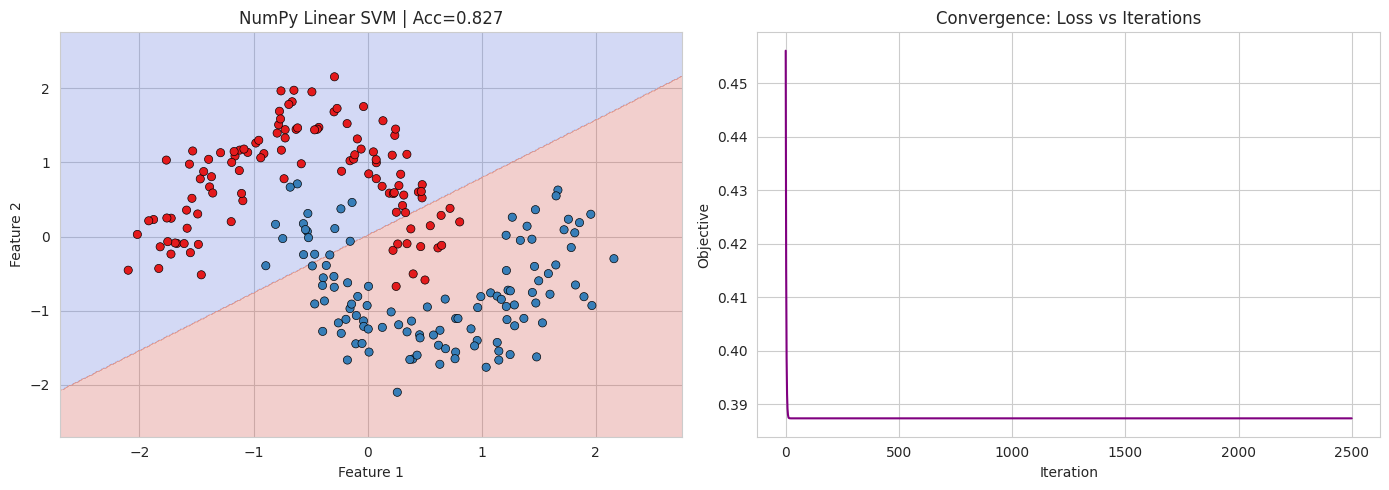

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [9]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

Linear SVC accuracy: 0.8400
RBF SVC accuracy:    0.9733


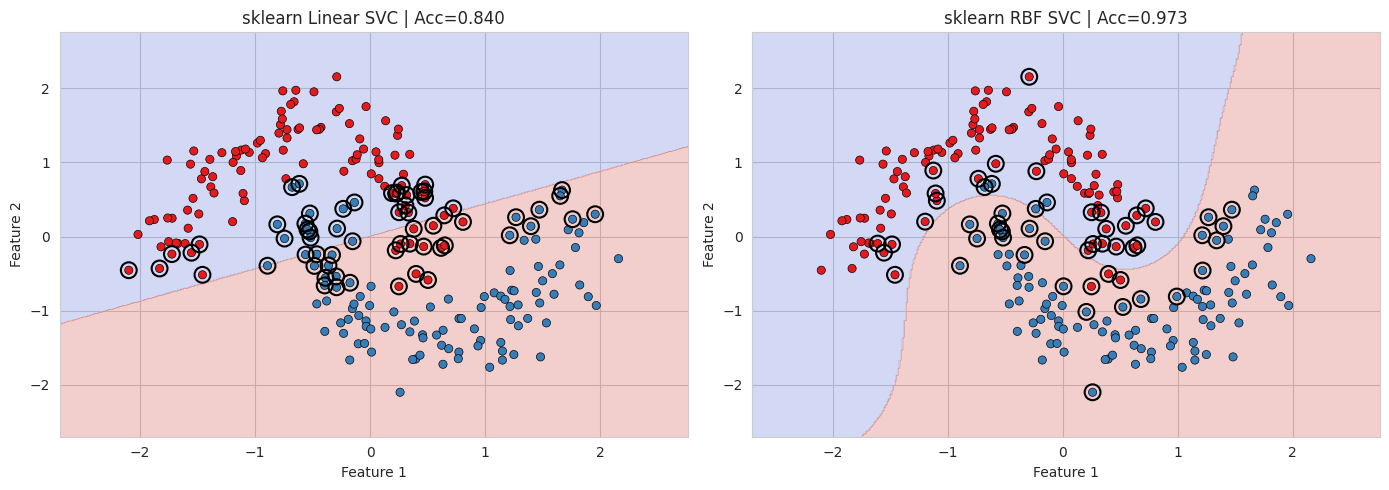

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

In [17]:
import numpy as np

class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def linear_kernel(self, X1, X2):
        return X1 @ X2.T

    def _objective(self, X, y):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y = np.where(y == 0, -1, 1)

        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        # Better initialization
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0

        self.loss_history = []

        for _ in range(self.n_iters):
            # ✅ shuffle each epoch (VERY IMPORTANT)
            indices = rng.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(n_samples):
                x_i = X_shuffled[i]
                y_i = y_shuffled[i]

                condition = y_i * (np.dot(x_i, self.w) + self.b)

                if condition >= 1:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    # ✅ divide by n_samples (mean hinge)
                    grad_w = self.w - self.C * y_i * x_i
                    grad_b = -self.C * y_i

                # update
                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # track proper objective
            self.loss_history.append(self._objective(X, y))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [20]:
svm_np = LinearSVMStudent(C=0.5, learning_rate=0.001, n_iters=2500)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

NumPy Linear SVM accuracy: 0.8267
sklearn LinearSVC accuracy: 0.8533


### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use sklearn with scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build implementation for linear and RBF kernels.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Best params: {'C': 0.1, 'gamma': 0.1}
               Model  Accuracy
0   NumPy Linear SVM  0.986667
1  sklearn LinearSVC  0.986667
2        RBF Untuned  0.986667
3          RBF Tuned  0.986667


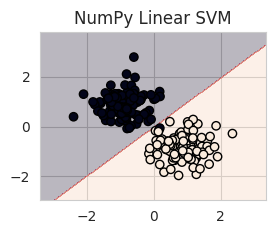

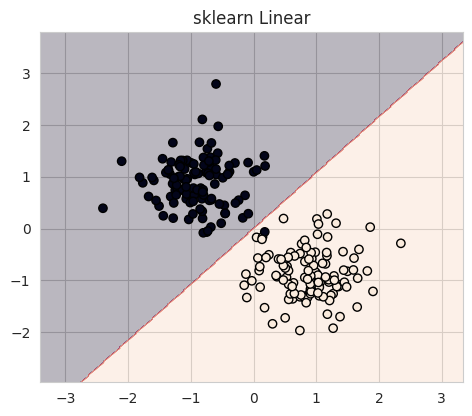

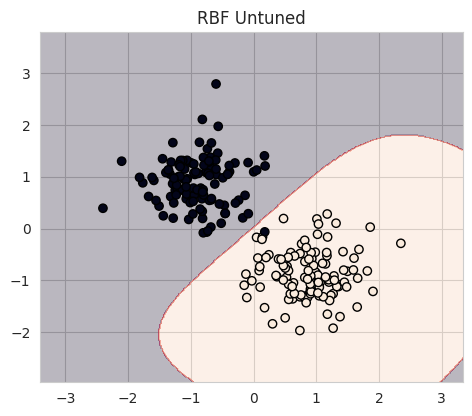

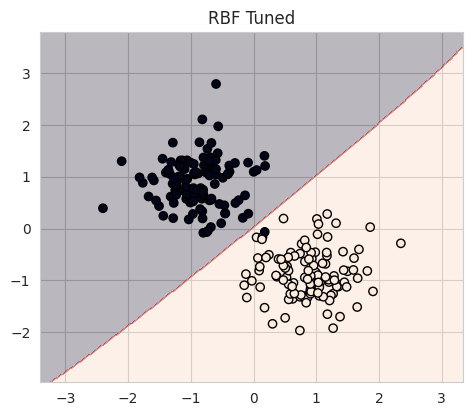

<Figure size 1200x1000 with 0 Axes>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

# Generate dataset (2D for visualization)
X, y = make_blobs(n_samples=300, centers=2, random_state=42, cluster_std=2.0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use your fixed LinearSVMStudent here
numpy_svm = LinearSVMStudent(C=1.0, learning_rate=0.001, n_iters=300)
numpy_svm.fit(X_train_scaled, y_train)
y_pred_numpy = numpy_svm.predict(X_test_scaled)
acc_numpy = accuracy_score(y_test, y_pred_numpy)

sklearn_linear = LinearSVC(C=1.0, max_iter=5000, random_state=42)
sklearn_linear.fit(X_train_scaled, y_train)

y_pred_linear = sklearn_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

sklearn_linear = LinearSVC(C=1.0, max_iter=5000, random_state=42)
sklearn_linear.fit(X_train_scaled, y_train)

y_pred_linear = sklearn_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

rbf_untuned = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_untuned.fit(X_train_scaled, y_train)

y_pred_rbf_untuned = rbf_untuned.predict(X_test_scaled)
acc_rbf_untuned = accuracy_score(y_test, y_pred_rbf_untuned)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_rbf = grid.best_estimator_

y_pred_rbf_tuned = best_rbf.predict(X_test_scaled)
acc_rbf_tuned = accuracy_score(y_test, y_pred_rbf_tuned)

print("Best params:", grid.best_params_)

results = pd.DataFrame({
    'Model': [
        'NumPy Linear SVM',
        'sklearn LinearSVC',
        'RBF Untuned',
        'RBF Tuned'
    ],
    'Accuracy': [
        acc_numpy,
        acc_linear,
        acc_rbf_untuned,
        acc_rbf_tuned
    ]
})

print(results)

def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)

    plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plot_decision_boundary(numpy_svm, X_train_scaled, y_train, "NumPy Linear SVM")

plt.subplot(2, 2, 2)
plot_decision_boundary(sklearn_linear, X_train_scaled, y_train, "sklearn Linear")

plt.subplot(2, 2, 3)
plot_decision_boundary(rbf_untuned, X_train_scaled, y_train, "RBF Untuned")

plt.subplot(2, 2, 4)
plot_decision_boundary(best_rbf, X_train_scaled, y_train, "RBF Tuned")

plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report. (below implemented)
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Keep one untouched test set for final evaluation.
- Mention overfitting signs (very high train vs lower test performance).

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc,
    test_size=0.2,
    stratify=y_bc,
    random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear SVM
linear_model = SVC(kernel='linear')

linear_param_grid = {
    'C': [0.1, 1, 10]
}

# RBF SVM
rbf_model = SVC(kernel='rbf')

rbf_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1]
}

# Linear tuning
grid_linear = GridSearchCV(
    linear_model,
    linear_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_linear.fit(X_train_scaled, y_train)

# RBF tuning
grid_rbf = GridSearchCV(
    rbf_model,
    rbf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rbf.fit(X_train_scaled, y_train)

print("Best Linear params:", grid_linear.best_params_)
print("Best RBF params:", grid_rbf.best_params_)

best_linear = grid_linear.best_estimator_
best_rbf = grid_rbf.best_estimator_

# Compare on validation (train CV already done, now quick check)
linear_train_score = best_linear.score(X_train_scaled, y_train)
rbf_train_score = best_rbf.score(X_train_scaled, y_train)

print("Linear train score:", linear_train_score)
print("RBF train score:", rbf_train_score)

# Choose best (usually RBF wins)
best_model = best_rbf

y_pred = best_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Linear params: {'C': 0.1}
Best RBF params: {'C': 10, 'gamma': 0.01}
Linear train score: 0.9846153846153847
RBF train score: 0.9868131868131869
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 5) Additional Notebook Sections

In [14]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


### Reflection Questions (5% bonus)
1. Why does RBF outperform linear on moons data?
2. How does increasing `C` affect margin and errors?
3. How does `gamma` control complexity in RBF?
4. Why is scaling essential for SVM?
5. What did convergence plots reveal in your NumPy model?